In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import seaborn as sns

# Load the dataset
df = pd.read_csv('pre-owned cars.csv')

In [3]:
df.head()

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


In [4]:
d = df.fuel_type.value_counts()

In [5]:
d

fuel_type
Petrol      2373
Diesel       318
CNG          110
Electric       4
Name: count, dtype: int64

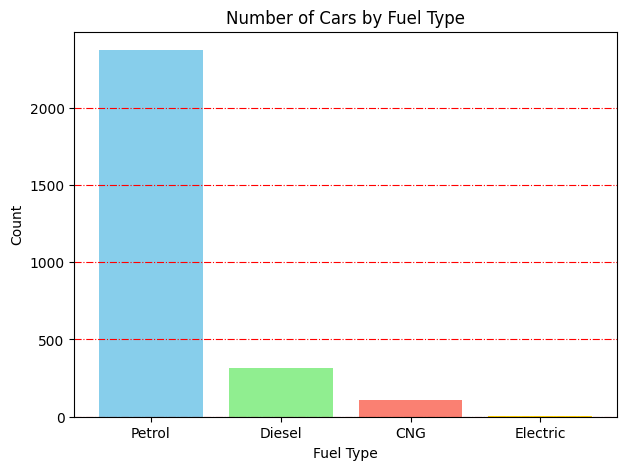

In [6]:
# Count the number of cars for each fuel type
fuel_counts = df['fuel_type'].value_counts()

plt.figure(figsize=(7, 5))
# Create a bar chart using the index as x and values as y
plt.bar(fuel_counts.index, fuel_counts.values, color=['skyblue', 'lightgreen', 'salmon', 'gold'])

plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='-.',color = 'red')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_26568\984016822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='fuel_type', y='price', palette='Set1')


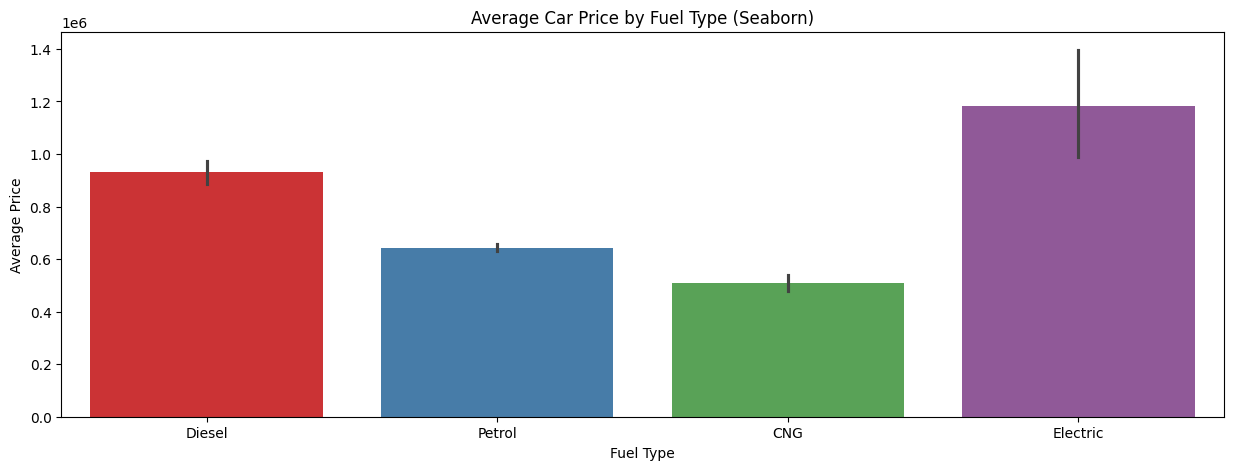

In [18]:
plt.figure(figsize=(15, 5))
# Create a bar plot using Seaborn
# It automatically aggregates multiple values for the same fuel_type (default is mean)
sns.barplot(data=df, x='fuel_type', y='price', palette='Set1')

plt.title('Average Car Price by Fuel Type (Seaborn)')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.show()

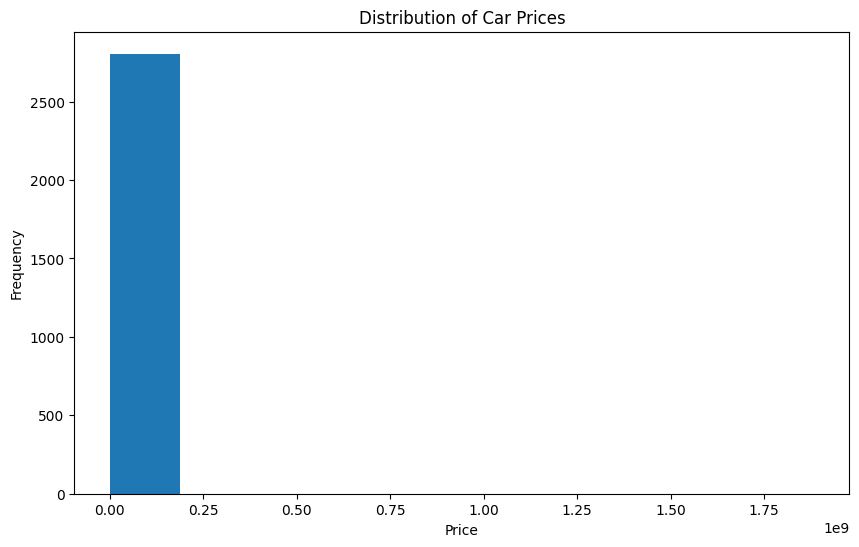

In [8]:
plt.figure(figsize=(10, 6))
# Create a histogram using Seaborn with a KDE curve and separated by 'spare_key'
plt.hist(data=df, x='price')

plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

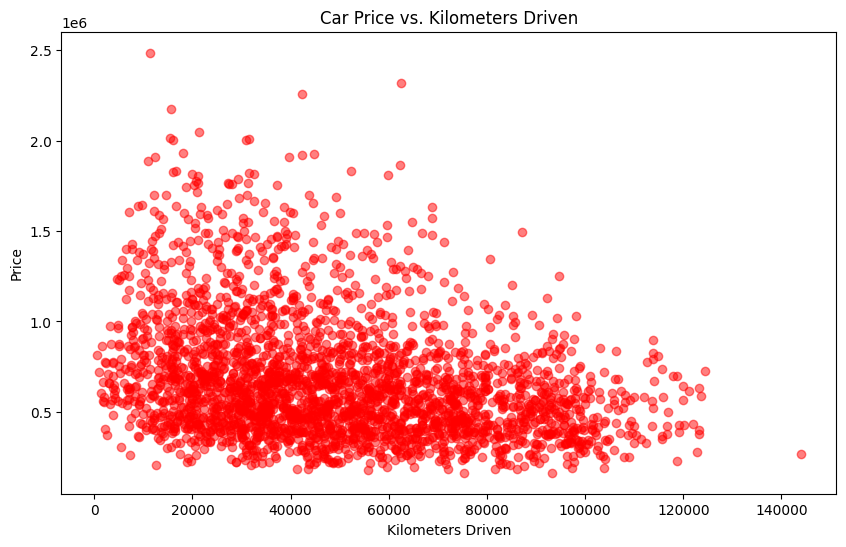

In [9]:
plt.figure(figsize=(10, 6))
# Scatter plot mapping km_driven to x-axis and price to y-axis
plt.scatter(df['km_driven'], df['price'], alpha=0.5, color='red')

plt.title('Car Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')
plt.show()

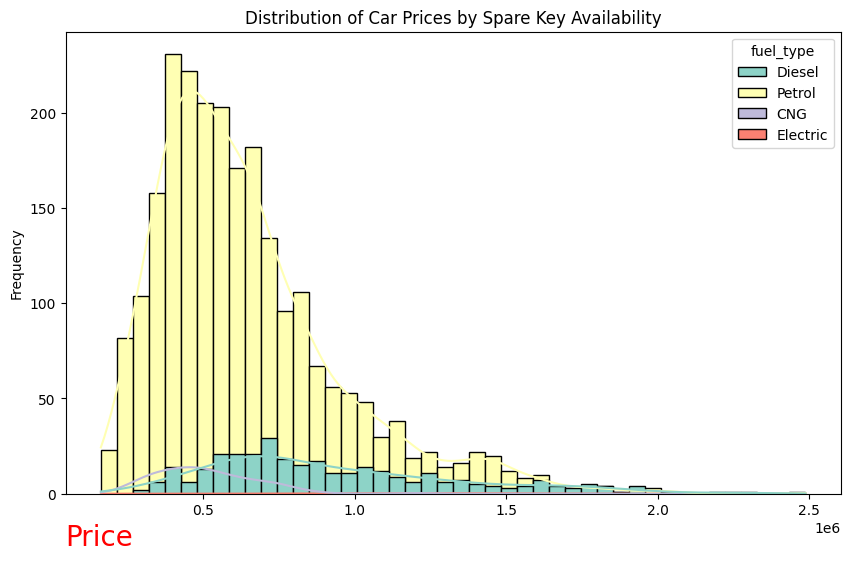

In [10]:
plt.figure(figsize=(10, 6))
# Create a histogram using Seaborn with a KDE curve and separated by 'spare_key'
sns.histplot(data=df, x='price', hue='fuel_type', kde=True,  palette='Set3', alpha=1)

plt.title('Distribution of Car Prices by Spare Key Availability')
plt.xlabel('Price', fontdict={'fontsize': 20}, color='Red', loc="left")
plt.ylabel('Frequency')
plt.show()

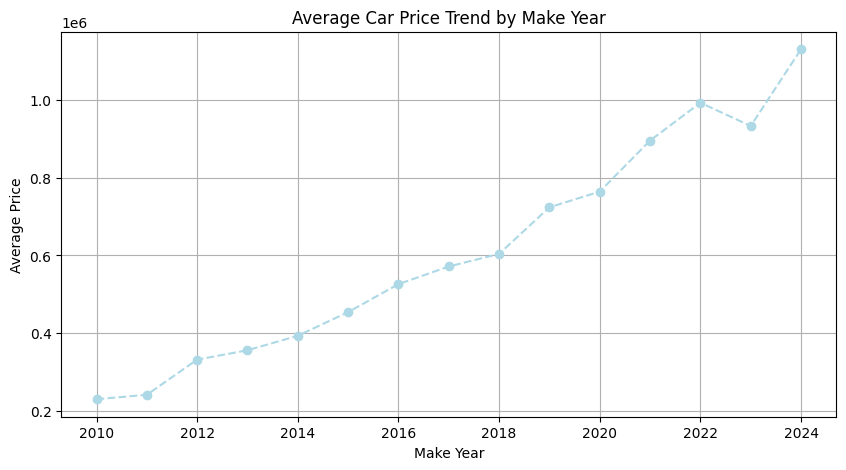

In [11]:
# Calculate the average price for each make_year
avg_price_per_year = df.groupby('make_year')['price'].mean().sort_index()

plt.figure(figsize=(10, 5))
# Plot line chart
plt.plot(avg_price_per_year.index, avg_price_per_year.values, marker='o', linestyle='--', color='lightblue')

plt.title('Average Car Price Trend by Make Year')
plt.xlabel('Make Year')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

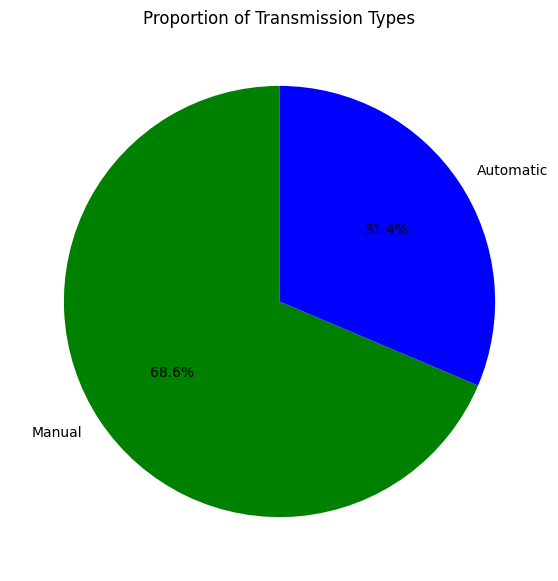

In [21]:
transmission_counts = df['transmission'].value_counts()

plt.figure(figsize=(7, 7))
# Create a pie chart
plt.pie(transmission_counts.values, labels=transmission_counts.index, autopct='%1.1f%%', startangle=90, colors=['green','blue'])

plt.title('Proportion of Transmission Types')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_26568\1544292922.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([first_owner_prices, second_owner_prices], labels=['1st Owner', '2nd Owner'])


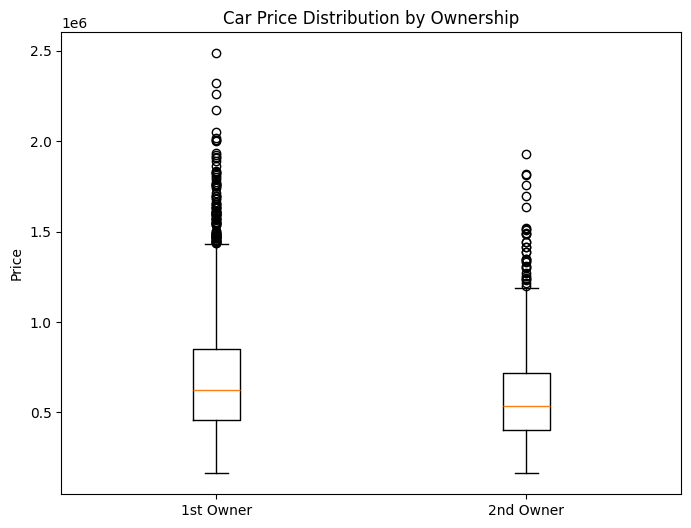

In [13]:
# We will use data for '1st owner' and '2nd owner' as an example
first_owner_prices = df[df['ownership'] == '1st owner']['price'].dropna()
second_owner_prices = df[df['ownership'] == '2nd owner']['price'].dropna()

plt.figure(figsize=(8, 6))
# Create the box plot
plt.boxplot([first_owner_prices, second_owner_prices], labels=['1st Owner', '2nd Owner'])

plt.title('Car Price Distribution by Ownership')
plt.ylabel('Price')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_26568\1583500518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='transmission',palette='flare')


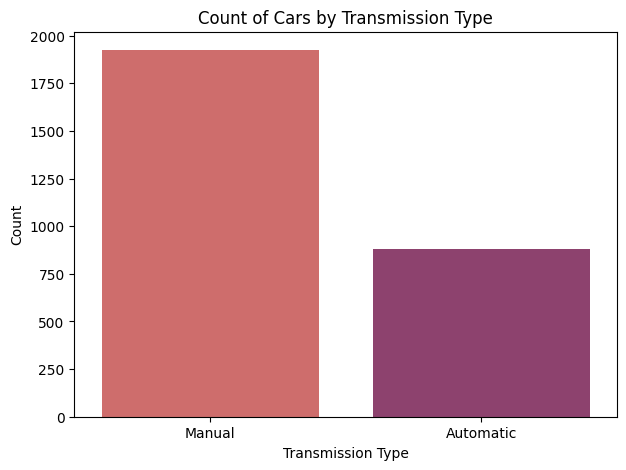

In [14]:
plt.figure(figsize=(7, 5))
# Create a count plot
sns.countplot(data=df, x='transmission',palette='flare')

plt.title('Count of Cars by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

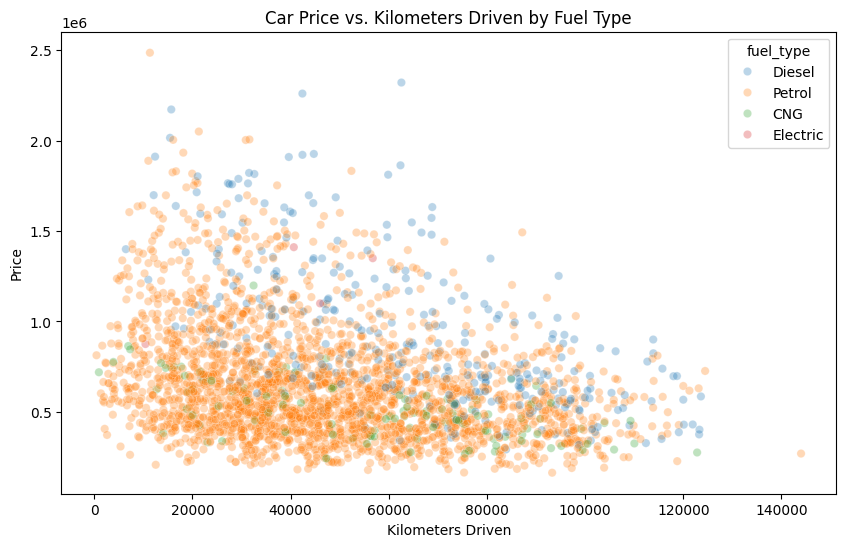

In [15]:
plt.figure(figsize=(10, 6))
# Scatter plot with hue to differentiate fuel types
sns.scatterplot(data=df, x='km_driven', y='price', hue='fuel_type', alpha=0.3)

plt.title('Car Price vs. Kilometers Driven by Fuel Type')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_26568\3961135332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ownership', y='price', palette='crest')


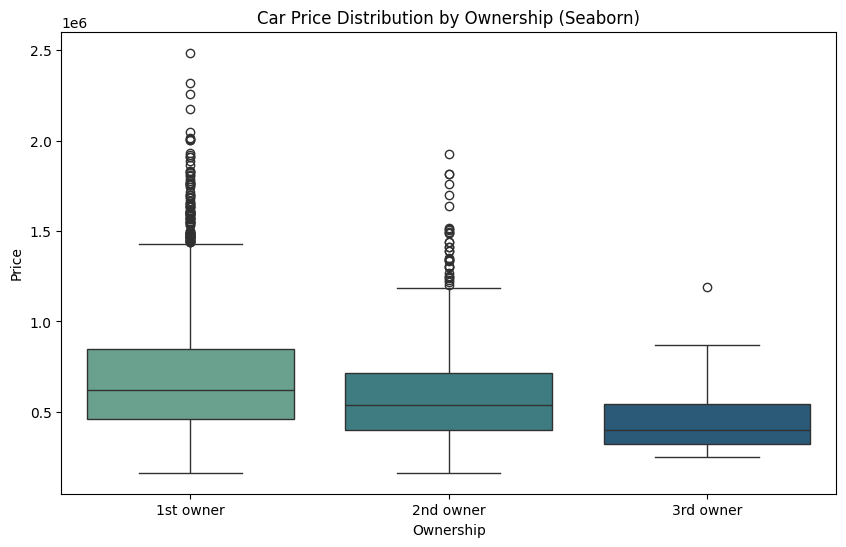

In [22]:
plt.figure(figsize=(10, 6))
# Create a box plot directly from the columns
sns.boxplot(data=df, x='ownership', y='price', palette='crest')

plt.title('Car Price Distribution by Ownership (Seaborn)')
plt.xlabel('Ownership')
plt.ylabel('Price')
plt.show()

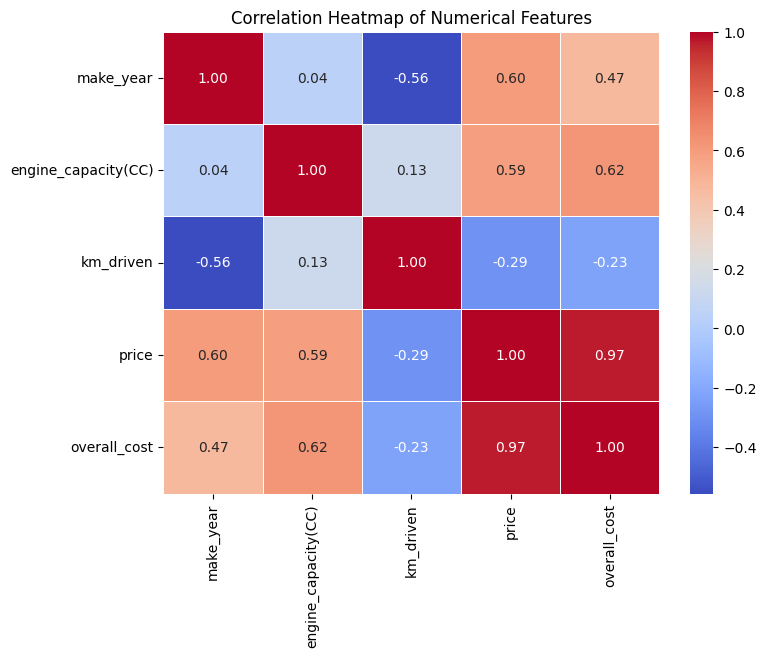

In [26]:
plt.figure(figsize=(8, 6))
# First, select only the numerical columns for correlation
numerical_df = df.select_dtypes(include=['int64', 'float64'])
# Compute the correlation matrix
corr_matrix = numerical_df.corr()
# corr_matrix


# Create a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()